# Tutorial 8: generative models: VAE, GAN, VQ tokens + an autoregressive prior
**Deep Learning 89-6877, Fall 2026.** TA: Tal Fiskus.

Recap slides: [T08_generative_models_recap.pdf](https://github.com/idansc/dl-course-2026/blob/main/tutorials/recap/T08_generative_models_recap.pdf)

Plan for today (≈ 70 min):
1. Lecture recap: autoregressive models, VAE and the ELBO, GANs, VQ-VAE, MaskGIT/VAR (12 min)
2. A VAE on MNIST: reparameterization, closed-form KL vs Monte Carlo, samples, interpolation (15 min)
3. A DCGAN on MNIST with the non-saturating loss (10 min)
4. A VQ layer: nearest code, straight-through gradient, codebook usage (12 min)
5. An autoregressive transformer over the VQ token grid (10 min)
6. Mode collapse: a GAN on 8 Gaussians, and minibatch statistics as a fix (10 min)
7. If time: MaskGIT-style parallel decoding

Everything runs on a laptop CPU in a few minutes (20k MNIST images, small nets, 1–6 epochs). On a Colab GPU, use all 60k images and 5–10× the epochs; the samples get much sharper. Cells marked ✏️ are for you to try.

In [1]:
import math, time, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
from torch.distributions import Normal, Bernoulli, kl_divergence

def seed_all(s=0):
    torch.manual_seed(s); random.seed(s); np.random.seed(s)
seed_all(0)
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)
T0 = time.time()

device: mps


## 1. Lecture recap

**Goal.** Learn $p_\theta(x)\approx p_{\text{data}}(x)$, then sample $x\sim p_\theta$. Three families: explicit density (autoregressive), approximate density (VAE), implicit density (GAN; diffusion next week).

**Autoregressive.** Chain rule, exact likelihood, trained with cross-entropy on the next element:
$$p(x)=\prod_{i=1}^{n} p(x_i\mid x_{<i}).$$
Sampling is sequential, so $n$ forward passes. On raw pixels $n$ is huge (a 1024² RGB image is 3M sub-pixels); on a 16×16 grid of VQ tokens it is 256.

**VAE.** Latent $z\sim p(z)=\mathcal N(0,I)$, decoder $p_\theta(x\mid z)$, encoder $q_\phi(z\mid x)=\mathcal N(\mu_\phi(x),\mathrm{diag}\,\sigma^2_\phi(x))$. For any $q$,
$$\log p_\theta(x) = \underbrace{\mathbb E_{q}\big[\log p_\theta(x\mid z)\big] - \mathrm{KL}\big(q_\phi(z\mid x)\,\|\,p(z)\big)}_{\text{ELBO}} \;+\; \mathrm{KL}\big(q_\phi(z\mid x)\,\|\,p_\theta(z\mid x)\big),$$
and the last term is $\ge 0$, so the ELBO is a lower bound on $\log p_\theta(x)$ (derivation: write $\log p(x)=\mathbb E_q[\log \frac{p(x,z)}{q(z|x)}\frac{q(z|x)}{p(z|x)}]$ and split the log). The lecture's form, $L=\lVert x-\hat x\rVert^2+\lambda\,\mathrm{KL}$, is the negative ELBO with a Gaussian decoder; with a Bernoulli decoder the first term is binary cross-entropy.
- Closed-form KL to the prior: $\mathrm{KL}\big(\mathcal N(\mu,\sigma^2)\|\mathcal N(0,1)\big)=\tfrac12\sum_j\big(\mu_j^2+\sigma_j^2-\log\sigma_j^2-1\big)$, minimized at $\mu=0,\sigma=1$.
- The encoder predicts $\log\sigma^2$, so any real output is a valid variance.
- **Reparameterization:** $z=\mu+\sigma\odot\epsilon$, $\epsilon\sim\mathcal N(0,I)$. The randomness moves into an input, and $\partial z/\partial\mu=1$, $\partial z/\partial\sigma=\epsilon$ are ordinary gradients.
- Generate: decode $z\sim\mathcal N(0,I)$. The KL term packs the codes of all inputs around the origin, so latent interpolation stays on the data; a plain autoencoder leaves empty pockets.

**GAN** (Goodfellow et al., 2014; no slides yet). A generator $G(z)$ and a discriminator $D(x)\in(0,1)$ play
$$\min_G\max_D\; \mathbb E_{x\sim p_{\text{data}}}[\log D(x)] + \mathbb E_{z}[\log(1-D(G(z)))].$$
For a fixed $G$ the optimal $D^*(x)=\frac{p_{\text{data}}(x)}{p_{\text{data}}(x)+p_G(x)}$; plugging it in gives $2\,\mathrm{JS}(p_{\text{data}}\|p_G)-\log 4$, minimized iff $p_G=p_{\text{data}}$. No likelihood, no encoder: $D$ is a learned loss.
- **Non-saturating loss.** Early in training $D(G(z))\approx 0$ and $\log(1-D(G(z)))$ is flat, so $G$ gets almost no gradient. In practice $G$ maximizes $\log D(G(z))$ instead. With logits $s$: $L_D=\mathrm{softplus}(-s_{\text{real}})+\mathrm{softplus}(s_{\text{fake}})$, $L_G=\mathrm{softplus}(-s_{\text{fake}})$.
- **DCGAN** (Radford et al., 2015): strided convs in $D$, transposed convs in $G$, BatchNorm, LeakyReLU in $D$, Adam with $\beta_1=0.5$.
- **Failure modes:** non-convergence (the two players oscillate) and **mode collapse** ($G$ covers a few modes that fool the current $D$). Section 6.

**VQ-VAE** (van den Oord et al., 2017). The encoder output $z_e(x)$ at every spatial position is replaced by its nearest codebook vector, $z_q=e_k$, $k=\arg\min_j\lVert z_e-e_j\rVert$. An image becomes a grid of integers. Loss, with $\mathrm{sg}$ = stop-gradient:
$$L=-\log p(x\mid z_q)+\lVert \mathrm{sg}[z_e]-e\rVert^2+\beta\,\lVert z_e-\mathrm{sg}[e]\rVert^2 .$$
The argmin has no gradient, so the decoder's gradient w.r.t. $z_q$ is copied to $z_e$ (**straight-through**). DALL·E's dVAE replaces the argmin with a Gumbel-softmax relaxation.

**Tokens + a prior.** Train a second model over the token grid and decode its samples: an autoregressive transformer in raster order (VQ-GAN, DALL·E), **MaskGIT** (predict all masked tokens in parallel, keep the most confident, re-mask the rest; ~8–12 steps instead of 256), **VAR** (predict the next *scale*: 1×1 → 2×2 → … token maps, coarse to fine).

### Data
20k MNIST training images, kept in memory as a tensor in $[0,1]$ (no DataLoader needed at this size).

In [2]:
train = torchvision.datasets.MNIST("./data", train=True, download=True)
test = torchvision.datasets.MNIST("./data", train=False, download=True)
N_TRAIN = 20_000                                  # Colab GPU: use all 60_000
X = train.data[:N_TRAIN].float().div(255).unsqueeze(1).to(device)   # (N, 1, 28, 28)
X_test = test.data[:1000].float().div(255).unsqueeze(1).to(device)
y_test = test.targets[:1000]

def batches(data, bs):
    perm = torch.randperm(len(data), device=data.device)
    for i in range(0, len(data) - bs + 1, bs):
        yield data[perm[i:i + bs]]

def show_grid(imgs, title, nrow=8, ax=None):
    grid = torchvision.utils.make_grid(imgs.detach().cpu().clamp(0, 1), nrow=nrow, pad_value=1)
    ax = ax or plt.figure(figsize=(nrow * 0.6, len(imgs) / nrow * 0.6 + 0.4)).gca()
    ax.imshow(grid.permute(1, 2, 0)); ax.set_title(title); ax.axis("off")
print(X.shape, X_test.shape)

torch.Size([20000, 1, 28, 28]) torch.Size([1000, 1, 28, 28])


## 2. VAE

Encoder: MLP 784 → 400 → ($\mu$, $\log\sigma^2$) in $\mathbb R^{16}$. Decoder: 16 → 400 → 784 Bernoulli logits.
Three pieces to write: the reparameterized sample, the closed-form KL, and the negative ELBO (per image, averaged over the batch).

In [3]:
def reparameterize(mu, logvar):
    eps = torch.randn_like(mu)
    return mu + torch.exp(0.5 * logvar) * eps

def kl_to_standard_normal(mu, logvar):
    # KL( N(mu, diag σ²) || N(0, I) ), summed over latent dims -> shape (batch,)
    return 0.5 * (mu.pow(2) + logvar.exp() - logvar - 1).sum(-1)

def negative_elbo(x_logits, x, mu, logvar):
    # per-image  −E_q[log p(x|z)] + KL, averaged over the batch; returns (loss, recon, kl)
    recon = F.binary_cross_entropy_with_logits(x_logits, x, reduction="none").flatten(1).sum(1)
    kl = kl_to_standard_normal(mu, logvar)
    return (recon + kl).mean(), recon.mean(), kl.mean()

class VAE(nn.Module):
    def __init__(self, z_dim=16, h=400):
        super().__init__()
        self.enc = nn.Sequential(nn.Flatten(), nn.Linear(784, h), nn.ReLU(), nn.Linear(h, 2 * z_dim))
        self.dec = nn.Sequential(nn.Linear(z_dim, h), nn.ReLU(), nn.Linear(h, 784), nn.Unflatten(1, (1, 28, 28)))
    def encode(self, x):
        mu, logvar = self.enc(x).chunk(2, dim=1)
        return mu, logvar
    def forward(self, x):
        mu, logvar = self.encode(x)
        return self.dec(reparameterize(mu, logvar)), mu, logvar

**Check 1: the closed-form KL.** Compare with `torch.distributions.kl_divergence`, and with a Monte-Carlo estimate $\mathrm{KL}\approx\frac1S\sum_s\big[\log q(z_s)-\log p(z_s)\big]$, $z_s\sim q$. The MC estimate is unbiased, and its standard error shrinks like $1/\sqrt S$: the error should stay within a few standard errors. Also check that the reparameterized samples have mean $\mu$ and std $\sigma$, and that the gradients through the sample are right: for $f=\tfrac12\sum_j z_j^2$ with $\mathbb E f=\tfrac12\sum_j(\mu_j^2+\sigma_j^2)$, the reparameterized estimate should give $\partial/\partial\mu_j=\mu_j$ and $\partial/\partial\log\sigma_j^2=\sigma_j^2/2$.

In [4]:
seed_all(0)
mu, logvar = torch.randn(4, 16, dtype=torch.float64), torch.randn(4, 16, dtype=torch.float64)
q, p = Normal(mu, torch.exp(0.5 * logvar)), Normal(torch.zeros(16, dtype=torch.float64), torch.ones(16, dtype=torch.float64))
mine = kl_to_standard_normal(mu, logvar)
print("closed form:          ", mine.numpy().round(3))
print("max |mine − torch|:    ", (mine - kl_divergence(q, p).sum(-1)).abs().max().item())
for S in [100, 1_000, 10_000, 100_000]:
    z = q.sample((S,))                                        # (S, 4, 16)
    ratio = (q.log_prob(z) - p.log_prob(z)).sum(-1)          # log q(z) − log p(z), one per sample
    mc, se = ratio.mean(0), ratio.std(0) / math.sqrt(S)       # estimate and its standard error
    print(f"MC, S={S:>7,}: max |MC − closed| = {(mc - mine).abs().max().item():.4f}   (standard error ≈ {se.mean().item():.4f})")

mu1, lv1 = torch.tensor([1.5, -2.0], requires_grad=True), torch.tensor([0.0, math.log(0.25)], requires_grad=True)
z = reparameterize(mu1.expand(200_000, 2), lv1.expand(200_000, 2))
print("sample mean", z.mean(0).detach().numpy().round(3), " (μ = [1.5, -2.0])")
print("sample std ", z.std(0).detach().numpy().round(3), " (σ = [1.0, 0.5])")
z.pow(2).mean().backward()          # E[z_j²] = μ_j² + σ_j², averaged over the 2 dims
print("∂/∂μ     :", mu1.grad.numpy().round(3), " analytic μ        =", mu1.detach().numpy())
print("∂/∂log σ²:", lv1.grad.numpy().round(3), " analytic σ²/2     =", (lv1.detach().exp() / 2).numpy())

closed form:           [17.389  7.905 14.938 20.186]
max |mine − torch|:     3.552713678800501e-15
MC, S=    100: max |MC − closed| = 1.9876   (standard error ≈ 0.8301)
MC, S=  1,000: max |MC − closed| = 0.2342   (standard error ≈ 0.2647)
MC, S= 10,000: max |MC − closed| = 0.0699   (standard error ≈ 0.0853)


MC, S=100,000: max |MC − closed| = 0.0510   (standard error ≈ 0.0269)
sample mean [ 1.5 -2. ]  (μ = [1.5, -2.0])
sample std  [1.  0.5]  (σ = [1.0, 0.5])
∂/∂μ     : [ 1.5 -2. ]  analytic μ        = [ 1.5 -2. ]
∂/∂log σ²: [0.5   0.124]  analytic σ²/2     = [0.5   0.125]


**Past exam question (Moed B, 2026).** When sampling in a VAE we draw from the latent distribution using the mean $\mu$ and the variance $\sigma^2$. This sampling step is not differentiable, so backpropagation cannot be performed directly through it. How can this problem be overcome?

**Answer.** The reparameterization trick: sample the noise from a fixed distribution and write $z$ as a deterministic, differentiable function of the parameters,
$$z=\mu+\sigma\odot\epsilon,\qquad \epsilon\sim\mathcal N(0,I).$$
The randomness is now in $\epsilon$, which does not depend on $\phi$, so $\partial z/\partial\mu=1$ and $\partial z/\partial\sigma=\epsilon$ are ordinary derivatives and the gradient of $\mathbb E_\epsilon[f(\mu+\sigma\epsilon)]$ is estimated by backpropagating through samples. The check below shows it in `torch.distributions`: `sample()` cuts the graph, `rsample()` is the reparameterized sample.

In [5]:
mu_r = torch.tensor([1.5], requires_grad=True); sig_r = torch.tensor([0.5], requires_grad=True)
z_plain = Normal(mu_r, sig_r).sample((5,))
print("sample():  requires_grad =", z_plain.requires_grad, " (no path from z back to μ, σ)")
torch.manual_seed(0)
z_rep = Normal(mu_r, sig_r).rsample((100_000,))
z_rep.pow(2).mean().backward()                      # E[z²] = μ² + σ²  →  ∂/∂μ = 2μ = 3,  ∂/∂σ = 2σ = 1
print("rsample(): ∂E[z²]/∂μ =", round(mu_r.grad.item(), 3), "(2μ = 3.0)   ∂E[z²]/∂σ =", round(sig_r.grad.item(), 3), "(2σ = 1.0)")

sample():  requires_grad = False  (no path from z back to μ, σ)
rsample(): ∂E[z²]/∂μ = 2.998 (2μ = 3.0)   ∂E[z²]/∂σ = 0.995 (2σ = 1.0)


**Check 2: the negative ELBO** against `torch.distributions` (Bernoulli log-likelihood + KL).

In [6]:
seed_all(0)
x = (torch.rand(8, 1, 28, 28) > 0.5).float()
logits, mu, logvar = torch.randn(8, 1, 28, 28), torch.randn(8, 16), torch.randn(8, 16)
loss, recon, kl = negative_elbo(logits, x, mu, logvar)
ref = (-Bernoulli(logits=logits).log_prob(x).flatten(1).sum(1)
       + kl_divergence(Normal(mu, torch.exp(0.5 * logvar)), Normal(0., 1.)).sum(1)).mean()
print(f"mine {loss.item():.4f}   torch.distributions {ref.item():.4f}   diff {abs(loss - ref).item():.2e}")

mine 630.3026   torch.distributions 630.3026   diff 0.00e+00


Train for a few epochs. We log the two terms separately: at initialization $q(z\mid x)\approx\mathcal N(0,I)$, so the KL starts near 0; it rises as soon as the encoder starts putting information about $x$ into $z$, while the reconstruction term falls.

epoch 0: −ELBO  153.2 = recon  138.9 + KL  14.3   (1s)


epoch 1: −ELBO  135.3 = recon  117.3 + KL  18.0   (2s)


epoch 2: −ELBO  128.2 = recon  107.8 + KL  20.4   (3s)


epoch 3: −ELBO  123.4 = recon  104.1 + KL  19.3   (4s)


epoch 4: −ELBO  115.7 = recon   94.7 + KL  21.0   (4s)


epoch 5: −ELBO  117.2 = recon   95.0 + KL  22.2   (5s)
test −ELBO: 116.0 nats/image  (so log p(x) ≥ -116.0)


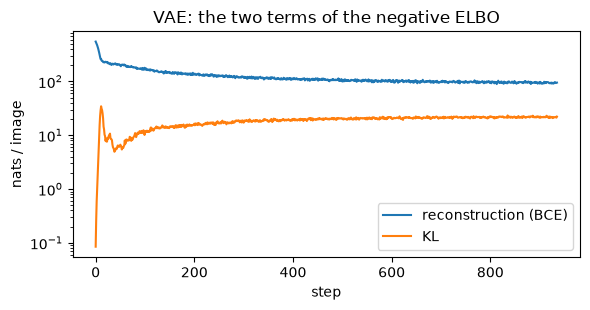

In [7]:
seed_all(0)
vae = VAE().to(device)
opt = torch.optim.Adam(vae.parameters(), lr=1e-3)
log = []
t = time.time()
for epoch in range(6):                            # Colab GPU: 30 epochs on 60k
    for x in batches(X, 128):
        logits, mu, logvar = vae(x)
        loss, recon, kl = negative_elbo(logits, x, mu, logvar)
        opt.zero_grad(); loss.backward(); opt.step()
        log.append((loss.item(), recon.item(), kl.item()))
    print(f"epoch {epoch}: −ELBO {loss.item():6.1f} = recon {recon.item():6.1f} + KL {kl.item():5.1f}   ({time.time() - t:.0f}s)")

with torch.no_grad():
    mu_t, lv_t = vae.encode(X_test)
    test_loss = negative_elbo(vae.dec(reparameterize(mu_t, lv_t)), X_test, mu_t, lv_t)[0].item()
print(f"test −ELBO: {test_loss:.1f} nats/image  (so log p(x) ≥ {-test_loss:.1f})")
log = np.array(log)
plt.figure(figsize=(6, 3.2))
plt.plot(log[:, 1], label="reconstruction (BCE)"); plt.plot(log[:, 2], label="KL")
plt.yscale("log"); plt.xlabel("step"); plt.ylabel("nats / image"); plt.title("VAE: the two terms of the negative ELBO"); plt.legend()
plt.tight_layout(); plt.show()

**Past exam question (Moed C, 2026).** A VAE trains two components: an encoder $q_\phi(z|x)$ and a decoder $p_\theta(x|z)$. The objective the model maximizes is the Evidence Lower Bound (ELBO):
$$\mathcal L_{\text{ELBO}}(x;\phi,\theta)=\mathbb E_{z\sim q_\phi(z|x)}\big[\log p_\theta(x|z)\big]-D_{KL}\big(q_\phi(z|x)\,\|\,p(z)\big),$$
where $p(z)=\mathcal N(0,I)$ is the prior over the latent space. **Explain the role of each of the two terms**, and what would happen to the sample quality and to the latent space if either one were dropped.

**Answer.**
- **Reconstruction** $\mathbb E_q[\log p_\theta(x|z)]$: the log-likelihood of $x$ under the decoder for codes drawn from the encoder (BCE here, MSE for a Gaussian decoder). It makes $z$ carry information about $x$ and trains the decoder to reproduce $x$ from it.
- **KL to the prior**: penalizes posteriors far from $\mathcal N(0,I)$. It keeps every $q(z|x)$ near the origin with non-zero width, so the codes of all inputs overlap and fill the region where the prior puts mass: the latent space is continuous, and decoding $z\sim\mathcal N(0,I)$ lands on codes the decoder was trained on. For one input with $\mu=(1,0)$, $\sigma=(0.5,1)$: $\mathrm{KL}=\tfrac12\big[(1+0.25-\log0.25-1)+(0+1-0-1)\big]=0.818$ nats.
- **Drop the KL**: a plain (noisy) autoencoder. Reconstructions get sharper, but the encoder places the codes anywhere, e.g. far from the origin with tiny $\sigma$, leaving gaps: samples from $\mathcal N(0,I)$ and interpolations fall in regions the decoder never saw and decode to garbage.
- **Drop the reconstruction term**: the objective is $-\mathrm{KL}$ alone, minimized by $q(z|x)=\mathcal N(0,I)$ for every $x$. The code carries no information about the input (posterior collapse), and the decoder receives no training signal at all, so its samples are unrelated to the data. (The official solution says the samples would be "averaged and without detail"; that describes a decoder trained on uninformative codes, i.e. a decoder term that is still present but ignored. With the term dropped the decoder is not trained at all.)

The check below computes the KL example and shows the effect of the KL term on the trained model: the codes of the test images have mean ≈ 0 and spread ≈ 1 per dimension, which is why decoding $z\sim\mathcal N(0,I)$ gives digits.

In [8]:
mu_k, sig_k = torch.tensor([1.0, 0.0]), torch.tensor([0.5, 1.0])
kl_k = 0.5 * (mu_k.pow(2) + sig_k.pow(2) - sig_k.pow(2).log() - 1).sum()
print(f"KL by hand {kl_k.item():.4f}   torch.distributions {kl_divergence(Normal(mu_k, sig_k), Normal(0., 1.)).sum().item():.4f}")
with torch.no_grad():
    z_test = reparameterize(*vae.encode(X_test))                  # one code per test image, (1000, 16)
print(f"trained VAE, test codes z ~ q(z|x): mean over images per dim in [{z_test.mean(0).min():.2f}, {z_test.mean(0).max():.2f}], "
      f"std per dim in [{z_test.std(0).min():.2f}, {z_test.std(0).max():.2f}]   (prior: 0 and 1)")

KL by hand 0.8181   torch.distributions 0.8181


trained VAE, test codes z ~ q(z|x): mean over images per dim in [-0.24, 0.39], std per dim in [0.99, 1.21]   (prior: 0 and 1)


**Samples and interpolations.** Samples: decode $z\sim\mathcal N(0,I)$ (we show the Bernoulli means, $\sigma(\text{logits})$). Interpolation: encode two test digits, decode points on the segment between their means $\mu_1,\mu_2$.

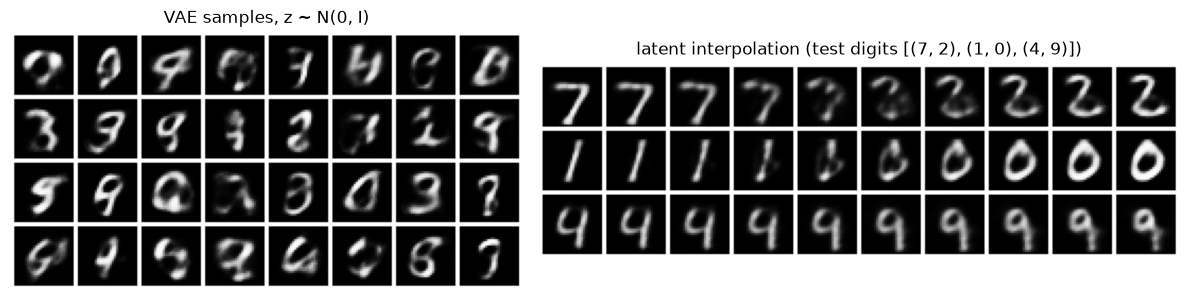

In [9]:
seed_all(1)
with torch.no_grad():
    samples = torch.sigmoid(vae.dec(torch.randn(32, 16, device=device)))
    pairs = [(0, 1), (2, 3), (4, 7)]               # indices into X_test
    rows = []
    for a, b in pairs:
        ma, mb = vae.encode(X_test[[a, b]])[0]
        alphas = torch.linspace(0, 1, 10, device=device)[:, None]
        rows.append(torch.sigmoid(vae.dec((1 - alphas) * ma + alphas * mb)))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), gridspec_kw={"width_ratios": [8, 10]})
show_grid(samples, "VAE samples, z ~ N(0, I)", nrow=8, ax=axes[0])
show_grid(torch.cat(rows), f"latent interpolation (test digits {[(y_test[a].item(), y_test[b].item()) for a, b in pairs]})", nrow=10, ax=axes[1])
plt.tight_layout(); plt.show()

The samples are blurry: the Bernoulli/Gaussian decoder averages over all images consistent with $z$, and 6 epochs of an MLP is little. The interpolations change digit identity smoothly, with plausible intermediate strokes: the decoder is defined on the whole segment because the KL term keeps all codes near the origin.

✏️ Set the KL weight to 0 (a plain autoencoder) and re-train: reconstructions improve, but samples from $\mathcal N(0,I)$ become garbage. Why? Then try $\beta=5$ (a β-VAE): what happens to the KL, the reconstructions and the samples?

**Past exam question (Moed B, 2026).** In a VAE with an encoder and a decoder with trained parameters $\phi,\theta$, it is known that after training one can interpolate smoothly between two examples $x_1,x_2$:
$$z_\alpha=(1-\alpha)z_1+\alpha z_2,\qquad z_i=\mathrm{Encoder}_\phi(x_i),\qquad \alpha\in[0,1],$$
and then compute $\mathrm{Decoder}_\theta(z_\alpha)$, which gives a smooth transition between the images. A student tried the same interpolation in the latent space of a regular autoencoder but got samples that are invalid or do not look like data. **Explain why linear interpolation in the latent space of a regular autoencoder can fail, and how the structure of its latent space differs from a VAE's.** Refer to the additional term in the VAE loss.

**Answer.** A plain autoencoder is trained only to reconstruct, so nothing constrains where codes go: each training image maps to a point, the points can sit in separate clusters far apart, and the decoder is trained only at those points. The segment between $z_1$ and $z_2$ can pass through regions no training code ever occupied, where the decoder's output is arbitrary, hence invalid intermediate images. The VAE adds $D_{KL}(q_\phi(z|x)\,\|\,p(z))$ with $p(z)=\mathcal N(0,I)$: each input is encoded as a distribution with non-zero width, centred near the origin. During training the decoder sees random points around every code, and the posteriors of different inputs overlap, so the region between codes is covered and decodes to plausible images; the latent space is continuous, and a segment between two codes stays in the region the decoder was trained on (the interpolation rows above). The ✏️ above (KL weight 0) is the experiment that shows the difference.

## 3. GAN

**Why the non-saturating loss.** Let $s$ be the discriminator logit on a fake, $D=\sigma(s)$. The minimax generator minimizes $\log(1-\sigma(s))$, with gradient $-\sigma(s)$; the non-saturating generator minimizes $-\log\sigma(s)$, with gradient $-(1-\sigma(s))$. At the start, $D$ easily rejects fakes ($s\ll 0$):

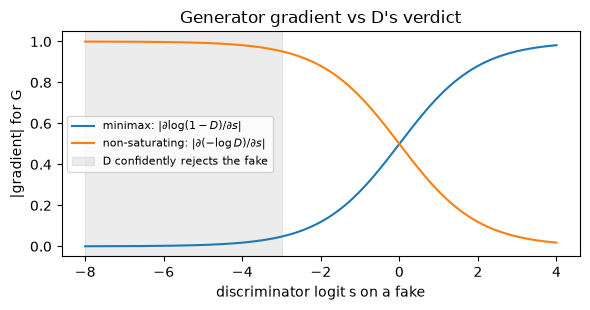

at s = -6 (D(G(z)) = 0.0024): minimax |grad| = 0.0024, non-saturating |grad| = 0.9976


In [10]:
s = torch.linspace(-8, 4, 200, requires_grad=True)
g_minimax, = torch.autograd.grad(torch.log(1 - torch.sigmoid(s)).sum(), s)
g_nonsat, = torch.autograd.grad((-torch.log(torch.sigmoid(s))).sum(), s)
plt.figure(figsize=(6, 3.2))
plt.plot(s.detach(), g_minimax.abs(), label=r"minimax: $|\partial \log(1-D)/\partial s|$")
plt.plot(s.detach(), g_nonsat.abs(), label=r"non-saturating: $|\partial (-\log D)/\partial s|$")
plt.axvspan(-8, -3, color="grey", alpha=0.15, label="D confidently rejects the fake")
plt.xlabel("discriminator logit s on a fake"); plt.ylabel("|gradient| for G"); plt.title("Generator gradient vs D's verdict"); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()
i = (s - (-6)).abs().argmin()
print(f"at s = -6 (D(G(z)) = {torch.sigmoid(s[i]).item():.4f}): minimax |grad| = {g_minimax[i].abs().item():.4f}, non-saturating |grad| = {g_nonsat[i].abs().item():.4f}")

In [11]:
def d_loss(real_logits, fake_logits):
    return F.softplus(-real_logits).mean() + F.softplus(fake_logits).mean()

def g_loss(fake_logits):
    return F.softplus(-fake_logits).mean()

seed_all(0)
r, f = torch.randn(64, 1) * 3, torch.randn(64, 1) * 3
ref_d = F.binary_cross_entropy_with_logits(r, torch.ones_like(r)) + F.binary_cross_entropy_with_logits(f, torch.zeros_like(f))
ref_g = F.binary_cross_entropy_with_logits(f, torch.ones_like(f))
print(f"D loss diff vs BCEWithLogits: {abs(d_loss(r, f) - ref_d).item():.2e}")
print(f"G loss diff vs BCEWithLogits: {abs(g_loss(f) - ref_g).item():.2e}")

D loss diff vs BCEWithLogits: 0.00e+00
G loss diff vs BCEWithLogits: 0.00e+00


**DCGAN for 28×28.** $G$: $z\in\mathbb R^{64}$ → linear to 64×7×7 → transposed conv to 32×14×14 → transposed conv to 1×28×28, sigmoid. $D$: two stride-2 convs (32, 64 channels) with LeakyReLU(0.2) → one logit. Adam, lr $2\cdot10^{-4}$, $\beta_1=0.5$. One $D$ step and one $G$ step per batch of 64.

step 500: L_D 0.236  L_G 4.400   (9s)


step 1000: L_D 0.327  L_G 1.558   (14s)


step 1500: L_D 0.261  L_G 2.207   (21s)


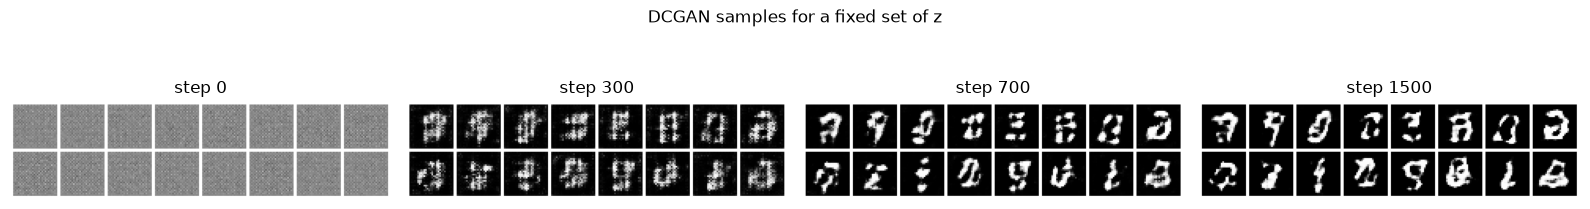

In [12]:
Z_DIM = 64
def make_G():
    return nn.Sequential(
        nn.Linear(Z_DIM, 64 * 7 * 7), nn.Unflatten(1, (64, 7, 7)), nn.BatchNorm2d(64), nn.ReLU(),
        nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(),
        nn.ConvTranspose2d(32, 1, 4, 2, 1), nn.Sigmoid())
def make_D():
    return nn.Sequential(
        nn.Conv2d(1, 32, 4, 2, 1), nn.LeakyReLU(0.2),
        nn.Conv2d(32, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
        nn.Flatten(), nn.Linear(64 * 7 * 7, 1))

seed_all(0)
G, D = make_G().to(device), make_D().to(device)
opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
z_fixed = torch.randn(32, Z_DIM, device=device)
STEPS, snap_at = 1500, {0, 300, 700}       # 1500 steps of batch 64 ≈ 5 epochs of 20k. Colab GPU: 10k steps on 60k
snapshots, gan_log, step, t = [], [], 0, time.time()
while step < STEPS:
    for x in batches(X, 64):
        if step in snap_at:
            G.eval(); snapshots.append((f"step {step}", G(z_fixed).detach())); G.train()
        fake = G(torch.randn(len(x), Z_DIM, device=device))
        lossD = d_loss(D(x), D(fake.detach()))      # detach: the D step must not update G
        opt_D.zero_grad(); lossD.backward(); opt_D.step()
        lossG = g_loss(D(fake))
        opt_G.zero_grad(); lossG.backward(); opt_G.step()
        gan_log.append((lossD.item(), lossG.item()))
        step += 1
        if step % 500 == 0:
            print(f"step {step}: L_D {lossD.item():.3f}  L_G {lossG.item():.3f}   ({time.time() - t:.0f}s)")
        if step == STEPS:
            break
G.eval(); snapshots.append((f"step {step}", G(z_fixed).detach())); G.train()

fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 2.6))
for ax, (title, imgs) in zip(axes, snapshots):
    show_grid(imgs[:16], title, nrow=8, ax=ax)
plt.suptitle("DCGAN samples for a fixed set of z"); plt.tight_layout(); plt.show()

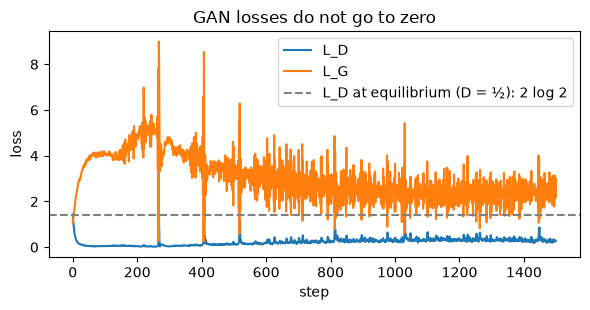

In [13]:
gl = np.array(gan_log)
plt.figure(figsize=(6, 3.2))
plt.plot(gl[:, 0], label="L_D"); plt.plot(gl[:, 1], label="L_G")
plt.axhline(2 * math.log(2), color="grey", ls="--", label="L_D at equilibrium (D = ½): 2 log 2")
plt.xlabel("step"); plt.ylabel("loss"); plt.title("GAN losses do not go to zero"); plt.legend()
plt.tight_layout(); plt.show()

The losses do not decrease, and they are not a measure of sample quality: each player's loss depends on the other. Here $D$ stays ahead the whole time ($L_D$ well below $2\log 2$, with spikes when $G$ briefly fools it), yet the samples keep improving. Look at samples (or FID) instead. After 1500 steps the strokes are sharp, but only some samples are clear digits (a 1, a 7, a 9) and most are still malformed: 1500 steps is short for a GAN; train 5–10× longer on a GPU. The VAE's samples were blurry but smooth. That is the usual trade: GANs give sharp samples and no likelihood; VAEs give a likelihood bound and blur.

✏️ Replace `g_loss` by the minimax version, `-F.softplus(fake_logits).mean()` (i.e. minimize $\log(1-D)$), and re-train. What do the first samples look like?

## 4. Vector quantization

A conv encoder maps 28×28 → a 7×7 grid of vectors $z_e\in\mathbb R^{16}$; each is snapped to the nearest of $K=64$ codebook vectors. The decoder only sees the codes, so an image *is* 49 integers in $[0,64)$.

Three pieces: nearest-code lookup (expand $\lVert z-e\rVert^2=\lVert z\rVert^2-2z^\top e+\lVert e\rVert^2$, one matmul), the straight-through estimator, and the two auxiliary losses.

In [14]:
def nearest_code(z, codebook):
    # z: (N, D), codebook: (K, D) -> indices (N,)
    d = z.pow(2).sum(1, keepdim=True) - 2 * z @ codebook.T + codebook.pow(2).sum(1)
    return d.argmin(1)

class VectorQuantizer(nn.Module):
    def __init__(self, K=64, dim=16, beta=0.25):
        super().__init__()
        self.codebook = nn.Embedding(K, dim)
        self.codebook.weight.data.uniform_(-1 / K, 1 / K)
        self.beta = beta

    def forward(self, z_e):                              # z_e: (B, D, H, W)
        B, D_, H, W = z_e.shape
        z = z_e.permute(0, 2, 3, 1).reshape(-1, D_)      # (B·H·W, D)
        idx = nearest_code(z, self.codebook.weight)
        z_q = self.codebook(idx)
        codebook_loss = F.mse_loss(z_q, z.detach())
        commit_loss = F.mse_loss(z, z_q.detach())
        z_st = z + (z_q - z).detach()
        z_st = z_st.view(B, H, W, D_).permute(0, 3, 1, 2)
        return z_st, idx.view(B, H, W), codebook_loss + self.beta * commit_loss

**Check 3: lookup, straight-through and gradient routing.** (a) the indices match `torch.cdist(...).argmin`; (b) the forward value is exactly $z_q$ and the gradient that reaches $z_e$ equals the upstream gradient w.r.t. $z_q$; (c) the codebook loss moves only the codebook, the commitment loss moves only the encoder output.

In [15]:
seed_all(0)
vq = VectorQuantizer(K=64, dim=16)
vq.codebook.weight.data.normal_()                       # spread out codes for the test
z_e = torch.randn(2, 16, 7, 7, requires_grad=True)
z_flat = z_e.detach().permute(0, 2, 3, 1).reshape(-1, 16)
print("(a) indices agree with cdist:", (nearest_code(z_flat, vq.codebook.weight) == torch.cdist(z_flat, vq.codebook.weight).argmin(1)).float().mean().item())

z_st, idx, _ = vq(z_e)
z_q = vq.codebook(idx).permute(0, 3, 1, 2)
print("(b) max |z_st − z_q| =", (z_st - z_q).abs().max().item())
upstream = torch.randn_like(z_st)
(z_st * upstream).sum().backward()
print("    max |∂/∂z_e − upstream| =", (z_e.grad - upstream).abs().max().item())

z_e.grad = None
z = z_e.permute(0, 2, 3, 1).reshape(-1, 16)
e = vq.codebook(nearest_code(z.detach(), vq.codebook.weight))
cb_loss, cm_loss = F.mse_loss(e, z.detach()), F.mse_loss(z, e.detach())
g = torch.autograd.grad(cb_loss, [z_e, vq.codebook.weight], allow_unused=True)
print("(c) codebook loss -> encoder grad:", g[0], "| codebook grad norm:", round(g[1].norm().item(), 4))
g = torch.autograd.grad(cm_loss, [z_e, vq.codebook.weight], allow_unused=True)
print("    commit loss   -> encoder grad norm:", round(g[0].norm().item(), 4), "| codebook grad:", g[1])

(a) indices agree with cdist: 1.0
(b) max |z_st − z_q| = 1.1920928955078125e-07
    max |∂/∂z_e − upstream| = 0.0
(c) codebook loss -> encoder grad: None | codebook grad norm: 0.0532
    commit loss   -> encoder grad norm: 0.0455 | codebook grad: None


In [16]:
class VQVAE(nn.Module):
    def __init__(self, K=64, dim=16):
        super().__init__()
        self.enc = nn.Sequential(nn.Conv2d(1, 32, 4, 2, 1), nn.ReLU(), nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
                                 nn.Conv2d(64, dim, 1))                          # (B, 16, 7, 7)
        self.vq = VectorQuantizer(K, dim)
        self.dec = nn.Sequential(nn.Conv2d(dim, 64, 3, 1, 1), nn.ReLU(),
                                 nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
                                 nn.ConvTranspose2d(32, 1, 4, 2, 1))            # logits (B, 1, 28, 28)
    def forward(self, x):
        z_q, idx, vq_loss = self.vq(self.enc(x))
        return self.dec(z_q), idx, vq_loss
    def decode_tokens(self, idx):                                               # (B, 7, 7) ints -> images
        return torch.sigmoid(self.dec(self.vq.codebook(idx).permute(0, 3, 1, 2)))

def usage(idx, K=64):
    counts = torch.bincount(idx.flatten().cpu(), minlength=K).float()
    p = counts / counts.sum()
    perplexity = torch.exp(-(p[p > 0] * p[p > 0].log()).sum()).item()          # effective number of codes
    return counts, int((counts > 0).sum()), perplexity

seed_all(0)
vqvae = VQVAE().to(device)
opt = torch.optim.Adam(vqvae.parameters(), lr=2e-3)
t = time.time()
for epoch in range(4):                            # Colab GPU: 20 epochs on 60k, K = 512
    for x in batches(X, 128):
        logits, idx, vq_loss = vqvae(x)
        rec = F.binary_cross_entropy_with_logits(logits, x, reduction="none").flatten(1).sum(1).mean()
        loss = rec + 49 * 16 * vq_loss            # vq losses are means over elements; ×(49 positions × 16 dims) = per-image sum, like rec
        opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        _, idx_t, _ = vqvae(X_test)
    _, used, ppl = usage(idx_t)
    print(f"epoch {epoch}: recon {rec.item():5.1f}  vq {vq_loss.item():.4f}  codes used {used}/64, perplexity {ppl:.1f}   ({time.time() - t:.0f}s)")

epoch 0: recon 107.0  vq 0.3642  codes used 5/64, perplexity 2.3   (1s)


epoch 1: recon  80.7  vq 0.0452  codes used 11/64, perplexity 6.3   (3s)


epoch 2: recon  73.1  vq 0.0216  codes used 22/64, perplexity 11.8   (5s)


epoch 3: recon  63.4  vq 0.0157  codes used 30/64, perplexity 18.0   (7s)


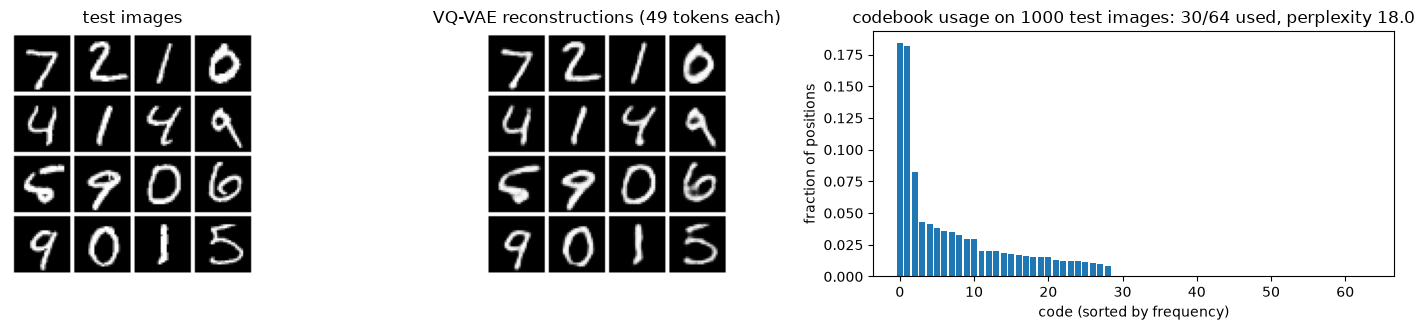

token grid of the first test digit:
 [[24  7  7  7  7  7 24]
 [10 20 20  9  9 28 10]
 [ 7 44 21 21 22 37 10]
 [ 7 10 57  9 52  7 24]
 [ 7  7 57 59 44 10 24]
 [ 7 10 20 22 57  7 24]
 [24 24 18 44 24 24 24]]


In [17]:
with torch.no_grad():
    logits, idx_t, _ = vqvae(X_test)
counts, used, ppl = usage(idx_t)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.4), gridspec_kw={"width_ratios": [4, 4, 5]})
show_grid(X_test[:16], "test images", nrow=4, ax=axes[0])
show_grid(torch.sigmoid(logits[:16]), "VQ-VAE reconstructions (49 tokens each)", nrow=4, ax=axes[1])
order = counts.argsort(descending=True)
axes[2].bar(range(64), counts[order] / counts.sum())
axes[2].set(title=f"codebook usage on 1000 test images: {used}/64 used, perplexity {ppl:.1f}", xlabel="code (sorted by frequency)", ylabel="fraction of positions")
plt.tight_layout(); plt.show()
print("token grid of the first test digit:\n", idx_t[0].cpu().numpy())

Reconstructions from 49 integers keep the digit and its stroke shape. The usage histogram is far from uniform: two codes (mostly background) take ~40% of all positions, only about half of the 64 codes are used at all, and the perplexity (the effective number of codes, $e^{H}$) is ~18. Usage grew every epoch (5 → ~30 codes), because codes are pulled in one by one as encoder outputs drift near them; a code that is never selected receives no gradient and never moves: a **dead code**, the classic VQ failure. Standard fixes: initialize the codebook from encoder outputs (k-means), re-initialize dead codes to random encoder outputs, EMA codebook updates, or $\ell_2$-normalized low-dimensional codes (ViT-VQGAN).

✏️ Implement dead-code restart: after each epoch, replace every code with count 0 by a random $z_e$ from the current batch. How do the number of used codes and the reconstruction loss change?

## 5. An autoregressive prior over the token grid

The VQ-VAE alone cannot generate: random token grids decode to noise. We need $p(\text{tokens})$. Flatten the 7×7 grid in raster order (49 tokens), prepend a BOS token, and train a small causal transformer with next-token cross-entropy, exactly as for text: $p(t)=\prod_{i=1}^{49}p(t_i\mid t_{<i})$.

**Connection to week 7.** Janus ([Wu et al., 2024](https://arxiv.org/abs/2410.13848)) generates images exactly this way: a VQ tokenizer turns the image into discrete tokens, and the LLM predicts them with next-token prediction, while a separate SigLIP encoder handles image *understanding*. The decoupling lets each encoder be good at its own job: pixel-level reconstructable codes for generation, semantic features for understanding.

### From earlier tutorials: a compact mini-GPT
Pre-norm blocks, causal self-attention via `F.scaled_dot_product_attention(is_causal=True)`, learned positional embeddings.

In [18]:
class Block(nn.Module):
    def __init__(self, d, n_heads):
        super().__init__()
        self.n_heads = n_heads
        self.ln1, self.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.qkv, self.proj = nn.Linear(d, 3 * d), nn.Linear(d, d)
        self.mlp = nn.Sequential(nn.Linear(d, 4 * d), nn.GELU(), nn.Linear(4 * d, d))
    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(self.ln1(x)).view(B, T, 3, self.n_heads, C // self.n_heads).permute(2, 0, 3, 1, 4)
        a = F.scaled_dot_product_attention(q, k, v, is_causal=True).transpose(1, 2).reshape(B, T, C)
        x = x + self.proj(a)
        return x + self.mlp(self.ln2(x))

class MiniGPT(nn.Module):
    def __init__(self, vocab, block_size, d=128, n_heads=4, n_layers=3):
        super().__init__()
        self.tok, self.pos = nn.Embedding(vocab, d), nn.Embedding(block_size, d)
        self.blocks = nn.Sequential(*[Block(d, n_heads) for _ in range(n_layers)])
        self.ln, self.head = nn.LayerNorm(d), nn.Linear(d, vocab)
    def forward(self, idx):                                   # (B, T) -> logits (B, T, vocab)
        x = self.tok(idx) + self.pos(torch.arange(idx.shape[1], device=idx.device))
        return self.head(self.ln(self.blocks(x)))

In [19]:
K, BOS = 64, 64                                         # codes 0..63, BOS = 64
with torch.no_grad():
    tokens = torch.cat([vqvae(x)[1].flatten(1) for x in X.split(1000)])   # (N, 49)
inp = torch.cat([torch.full((len(tokens), 1), BOS, device=device), tokens[:, :-1]], 1)  # BOS, t_1..t_48

seed_all(0)
gpt = MiniGPT(vocab=K + 1, block_size=49, d=96, n_heads=4, n_layers=2).to(device)
opt = torch.optim.AdamW(gpt.parameters(), lr=1e-3, weight_decay=0.01)
t, ar_log = time.time(), []
for step in range(1200):                              # Colab GPU: 10k steps, d=256, 6 layers
    b = torch.randint(0, len(tokens), (128,), device=device)
    logits = gpt(inp[b])
    loss = F.cross_entropy(logits[..., :K].reshape(-1, K), tokens[b].reshape(-1))   # BOS is never a target
    opt.zero_grad(); loss.backward(); opt.step()
    ar_log.append(loss.item())
    if step % 300 == 0 or step == 1199:
        print(f"step {step:4d}  loss {loss.item():.3f} nats/token   ({time.time() - t:.0f}s)")
print(f"uniform over 64 codes would be log 64 = {math.log(64):.3f} nats/token")

step    0  loss 4.313 nats/token   (0s)


step  300  loss 1.350 nats/token   (6s)


step  600  loss 1.278 nats/token   (11s)


step  900  loss 1.204 nats/token   (17s)


step 1199  loss 1.170 nats/token   (22s)
uniform over 64 codes would be log 64 = 4.159 nats/token


**Sampling.** Start from BOS; at each of the 49 positions run the model on the prefix, take the last logits, divide by the temperature, sample. Also accumulate the log-probability of each sampled token: by the chain rule their sum is $\log p(t)$ of the whole grid.

In [20]:
@torch.no_grad()
def sample_tokens(model, n, temperature=1.0, length=49):
    seq = torch.full((n, 1), BOS, device=device)
    logp = torch.zeros(n, device=device)
    for _ in range(length):
        logits = model(seq)[:, -1, :K] / temperature
        nxt = torch.multinomial(F.softmax(logits, -1), 1)
        logp += F.log_softmax(logits, -1).gather(1, nxt).squeeze(1)
        seq = torch.cat([seq, nxt], 1)
    return seq[:, 1:], logp

**Check 4: the chain rule.** One teacher-forced forward pass over the sampled grid gives all 49 conditionals at once (that is why training is parallel). Their summed log-probs must equal what the sampler accumulated step by step. If the attention mask leaked the future, they would not.

In [21]:
seed_all(0)
toks, logp_seq = sample_tokens(gpt, 8)
x_in = torch.cat([torch.full((8, 1), BOS, device=device), toks[:, :-1]], 1)
with torch.no_grad():
    logp_par = F.log_softmax(gpt(x_in)[..., :K], -1).gather(2, toks[..., None]).squeeze(-1).sum(1)
print("log p(t), sequential:", logp_seq.cpu().numpy().round(2))
print("log p(t), one pass:  ", logp_par.cpu().numpy().round(2))
print("max |diff| =", (logp_seq - logp_par).abs().max().item())

log p(t), sequential: [-64.02 -46.37 -68.35 -74.61 -74.72 -55.81 -64.93 -69.9 ]
log p(t), one pass:   [-64.02 -46.37 -68.35 -74.61 -74.72 -55.81 -64.93 -69.9 ]
max |diff| = 1.52587890625e-05


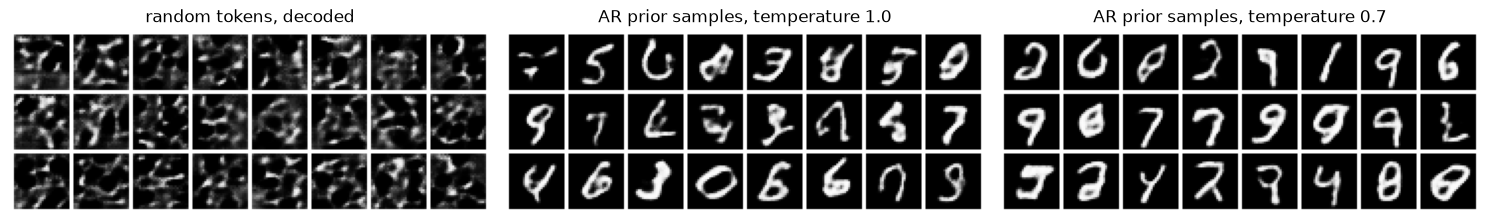

In [22]:
seed_all(2)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.2))
rand_tokens = torch.randint(0, K, (24, 7, 7), device=device)
show_grid(vqvae.decode_tokens(rand_tokens), "random tokens, decoded", nrow=8, ax=axes[0])
for ax, temp in zip(axes[1:], [1.0, 0.7]):
    toks, _ = sample_tokens(gpt, 24, temperature=temp)
    show_grid(vqvae.decode_tokens(toks.view(-1, 7, 7)), f"AR prior samples, temperature {temp}", nrow=8, ax=ax)
plt.tight_layout(); plt.show()

Random token grids decode to scattered stroke fragments: the decoder is fine, the tokens are wrong. Samples from the learned prior are digit-shaped, with some malformed ones; lowering the temperature trades diversity for cleaner samples, as for text. This two-stage recipe (tokenizer, then a prior over tokens) is VQ-VAE-2, VQ-GAN, DALL·E 1, Parti and the image head of Janus. **MaskGIT** keeps the tokenizer and replaces the raster-order prior by a bidirectional transformer that fills in masked tokens in parallel; **VAR** keeps a GPT but predicts a whole token map of the next resolution per step.

✏️ Sampling takes 49 forward passes, each over the whole prefix. Add a KV-cache (or count the FLOPs you would save).

## 6. Mode collapse

**Setup.** Data: a mixture of 8 Gaussians on a circle of radius 2 (std 0.05). $G$ and $D$: MLPs with two hidden layers of 128 units. The same non-saturating loss as in section 3. Adam, with a fast generator (lr $10^{-3}$) and a slower discriminator ($3\cdot10^{-4}$), 3000 steps; the imbalance makes collapse easy to see in a short run. (With equal rates of $10^{-3}$ the standard GAN on this ring also goes through a long collapse-and-hop phase, but usually covers most modes after ~3000 steps.) A mode counts as **covered** if at least 2% of 2000 generated points land within $3\sigma$ of its center; we also report the fraction of "high-quality" points (within $3\sigma$ of any center).

**Why it collapses.** $G$ is never asked to cover the data, only to fool the current $D$. If $D$ is weak on one mode, the best move for $G$ is to put more mass there; then $D$ learns to reject that mode, and $G$ hops to another. $D$ sees each sample alone, so it cannot tell "every sample is in mode 3" from "this sample is in mode 3".

**Fix: minibatch statistics** (Salimans et al., 2016; the minibatch-std layer of Karras et al., 2018). Give $D$ one extra feature: the standard deviation over the batch, averaged over features, appended to every sample. A real batch spans 8 modes and has std ≈ 1.4 per coordinate; a collapsed fake batch has a small one, so $D$ can reject it as a whole, and $G$ must spread out to fool it. Here we append it to $D$'s 2-D input; ProGAN/StyleGAN append it before the last block of $D$. Real and fake batches go through $D$ separately, so the statistic is computed per batch type.

In [23]:
RING_STD = 0.05
centers = torch.tensor([[2 * math.cos(k * math.pi / 4), 2 * math.sin(k * math.pi / 4)] for k in range(8)])

def sample_ring(n):
    k = torch.randint(0, 8, (n,))
    return centers[k] + RING_STD * torch.randn(n, 2)

def mode_coverage(x):
    d = torch.cdist(x, centers)
    dist, nearest = d.min(1)
    good = dist < 3 * RING_STD
    counts = torch.bincount(nearest[good], minlength=8)
    return int((counts >= 0.02 * len(x)).sum()), good.float().mean().item()

class MinibatchStd(nn.Module):
    def forward(self, h):                      # h: (B, F) -> (B, F + 1)
        s = h.std(0).mean()
        return torch.cat([h, s.expand(h.shape[0], 1)], 1)

h = torch.randn(5, 3)
print("shape:", tuple(MinibatchStd()(h).shape), " extra feature:", MinibatchStd()(h)[0, -1].item(), " expected:", torch.std(h, dim=0).mean().item())
print("a collapsed batch has a small one:", MinibatchStd()(torch.ones(5, 3) + 0.01 * torch.randn(5, 3))[0, -1].item())

shape: (5, 4)  extra feature: 0.8308136463165283  expected: 0.8308136463165283
a collapsed batch has a small one: 0.00656045600771904


In [24]:
RING_CFG = dict(steps=3000, lr_G=1e-3, lr_D=3e-4, z_dim=16, hidden=128, batch=128)

def train_ring_gan(minibatch_std, seed, steps, lr_G, lr_D, z_dim, hidden, batch, snap_every=500):
    seed_all(seed)
    G = nn.Sequential(nn.Linear(z_dim, hidden), nn.ReLU(), nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, 2))
    head = [MinibatchStd(), nn.Linear(3, hidden)] if minibatch_std else [nn.Linear(2, hidden)]   # (x1, x2[, batch std])
    D = nn.Sequential(*head, nn.ReLU(), nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, 1))
    oG = torch.optim.Adam(G.parameters(), lr_G, betas=(0.5, 0.999))
    oD = torch.optim.Adam(D.parameters(), lr_D, betas=(0.5, 0.999))
    snaps, z_eval = [], torch.randn(2000, z_dim)
    for step in range(1, steps + 1):
        fake = G(torch.randn(batch, z_dim))
        lossD = d_loss(D(sample_ring(batch)), D(fake.detach()))
        oD.zero_grad(); lossD.backward(); oD.step()
        lossG = g_loss(D(fake))
        oG.zero_grad(); lossG.backward(); oG.step()
        if step % snap_every == 0:
            with torch.no_grad():
                pts = G(z_eval)                                  # minibatch-std is in D only; G is evaluated alone
            snaps.append((step, pts, *mode_coverage(pts)))
    return snaps

t = time.time()
runs = {"standard GAN": train_ring_gan(False, 0, **RING_CFG), "+ minibatch std in D": train_ring_gan(True, 0, **RING_CFG)}
print(f"({time.time() - t:.0f}s)")
for name, snaps in runs.items():
    print(f"{name:22s} modes covered every 500 steps: {[c for _, _, c, _ in snaps]}   final high-quality fraction {snaps[-1][3]:.2f}")

(13s)
standard GAN           modes covered every 500 steps: [0, 1, 1, 1, 1, 0]   final high-quality fraction 0.00
+ minibatch std in D   modes covered every 500 steps: [2, 8, 8, 8, 8, 8]   final high-quality fraction 0.68


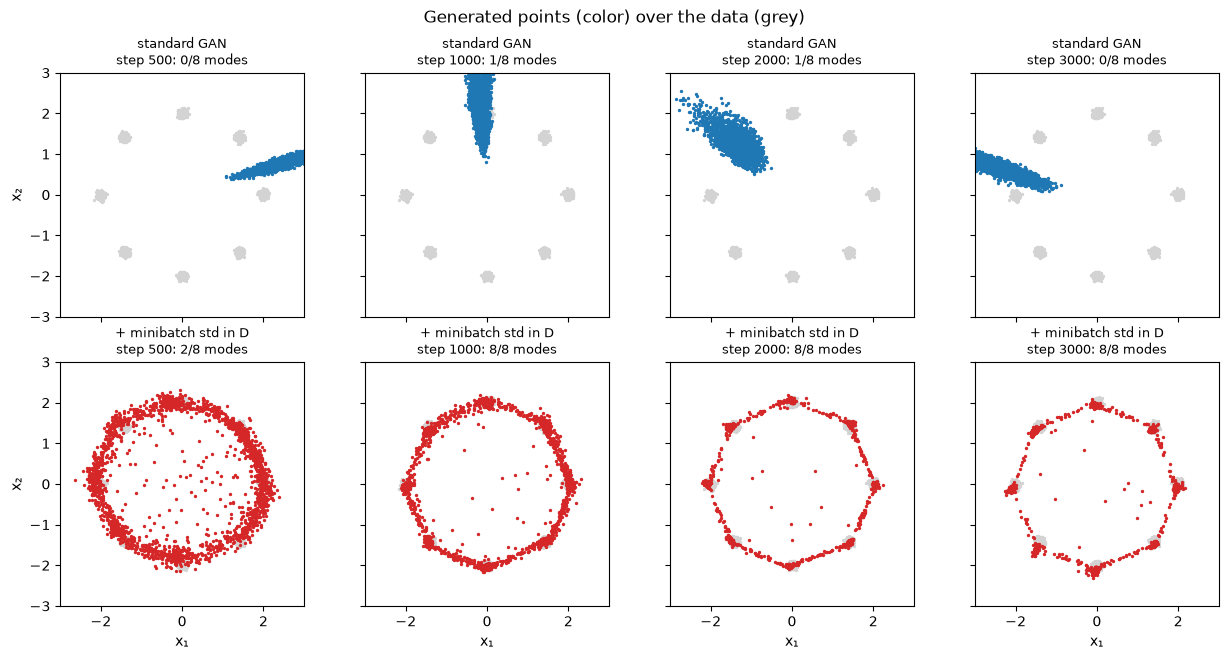

In [25]:
show_steps = [500, 1000, 2000, 3000]
real = sample_ring(2000)
fig, axes = plt.subplots(2, len(show_steps), figsize=(3.2 * len(show_steps), 6.6), sharex=True, sharey=True)
for row, (name, snaps) in zip(axes, runs.items()):
    by_step = {s: (p, c, q) for s, p, c, q in snaps}
    for ax, s in zip(row, show_steps):
        p, c, q = by_step[s]
        ax.scatter(real[:, 0], real[:, 1], s=2, c="lightgrey")
        ax.scatter(p[:, 0], p[:, 1], s=2, c="C3" if "minibatch" in name else "C0")
        ax.set_title(f"{name}\nstep {s}: {c}/8 modes", fontsize=9); ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect("equal")
for ax in axes[-1]: ax.set_xlabel("x₁")
for ax in axes[:, 0]: ax.set_ylabel("x₂")
plt.suptitle("Generated points (color) over the data (grey)"); plt.tight_layout(); plt.show()

The standard GAN puts all of its 2000 points into one elongated blob that **moves around the ring** between snapshots (0–1 of 8 modes, and the blob often sits *between* modes, so almost no point is "high quality"). This is the hopping behavior described above: $G$ chases whatever region $D$ currently scores as real. With the minibatch-std feature the same $G$, loss and learning rates cover the whole ring by step 1000 and all 8 modes after that; by step 3000 the points concentrate on the modes, with a thin trail of points between neighbouring modes (a continuous $G$ maps the connected $z$-space onto the ring, so it cannot jump between modes without leaving a trail).

One seed can be lucky. Mode coverage over 3 seeds, final step:

In [26]:
t = time.time()
for name, mbstd in [("standard GAN", False), ("+ minibatch std in D", True)]:
    finals = [train_ring_gan(mbstd, s, **RING_CFG)[-1] for s in range(1, 4)]
    print(f"{name:22s} modes covered (seeds 1-3): {[c for _, _, c, _ in finals]}   high-quality fraction: {[round(q, 2) for *_, q in finals]}")
print(f"({time.time() - t:.0f}s)")

standard GAN           modes covered (seeds 1-3): [0, 1, 0]   high-quality fraction: [0.02, 0.03, 0.01]


+ minibatch std in D   modes covered (seeds 1-3): [8, 8, 8]   high-quality fraction: [0.9, 0.88, 0.89]
(38s)


The result holds for every seed: the standard GAN covers 0–1 modes, the minibatch-std GAN 8/8 with ~90% of points on a mode. The fix costs one feature, but it is not free in general: it ties samples in a batch together, so $D$'s output for one sample depends on the others.

✏️ Other fixes to try on the same ring, with the same coverage count: PacGAN (feed $D$ 4 samples concatenated, `D(x.view(-1, 8))`); the Wasserstein loss with gradient penalty; or simply a smaller learning rate for $G$. Which one gives 8/8 modes for every seed?

## 7. If time: MaskGIT-style parallel decoding

MaskGIT trains a **bidirectional** transformer on token grids where a random fraction $r\sim\cos$-schedule of the tokens is replaced by `[MASK]`, with cross-entropy on the masked positions only. Sampling, with $T\approx 8$ steps:
1. start with all 49 positions masked;
2. predict all masked tokens in parallel, sample one per position, and score each by its probability;
3. keep the most confident ones, re-mask the rest so that a fraction $\cos(\frac{\pi}{2}\frac{t}{T})$ is still masked;
4. repeat until nothing is masked.

✏️ Turn `MiniGPT` into this: `is_causal=False`, a `MASK` token id 65, input = tokens with masked positions replaced, loss on masked positions only. Train for 1500 steps on `tokens` and sample with $T=8$ (8 forward passes instead of 49). Compare the samples with section 5.

## Summary
- **VAE**: maximize the ELBO = reconstruction − KL to the prior. The closed-form Gaussian KL matches a Monte-Carlo estimate (error ∝ $1/\sqrt S$); the reparameterization $z=\mu+\sigma\epsilon$ makes the sample differentiable. Smooth latent space, blurry samples.
- **GAN**: a learned discriminator is the loss. Use the non-saturating generator loss: at $D(G(z))\approx 0$ the minimax gradient is ~400× smaller. Sharp samples, no likelihood, the losses do not track quality.
- **VQ**: nearest-code lookup + straight-through gradient + codebook/commitment losses turn an image into a grid of integers. Watch codebook usage: unused codes never get gradient.
- **Tokens + a prior**: a next-token transformer over the VQ grid is a generator; the chain-rule check shows that one parallel pass gives exactly the sequential sampler's log-probability. MaskGIT and VAR change the order of generation, not the tokenizer.
- **Mode collapse**: a GAN can fool each $D$ with a few modes; giving $D$ a batch-level statistic lets it detect a collapsed batch.

**Further watching:** Stanford CS231n (2017), Lecture 13, *Generative Models* ([video](https://www.youtube.com/watch?v=5WoItGTWV54)); Stanford CS236, *Deep Generative Models* ([course site](https://deepgenerativemodels.github.io/)); Stanford CME 296 (2026), Lecture 4, *VAEs and latent space* ([slides](https://cme296.stanford.edu/slides/spring26-cme296-lecture4.pdf)).

In [27]:
print(f"total notebook time: {time.time() - T0:.0f}s")

total notebook time: 111s
